# ☀️ Solar Power Forecasting — 1-Hour Ahead Prediction
**Model:** LightGBM  
**Target:** `target_solar_1h` — total AC power output 60 minutes ahead  
**Data sources:** InfluxDB (inverter telemetry + weather observations) · Open-Meteo Historical Forecast API

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import dotenv
import os

from influxdb_client import InfluxDBClient
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# ── InfluxDB connection settings ──────────────────────────────
INFLUX_URL   = "https://influx.htetarkar.online"
INFLUX_TOKEN = os.getenv("influxdb_token")  # ← fill in your token
INFLUX_ORG   = "essco"
INFLUX_BUCKET = "essco_energy_data"

client    = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
query_api = client.query_api()

print("✅ InfluxDB client initialised")
print(f"   URL : {INFLUX_URL}")
print(f"   Org : {INFLUX_ORG}")
print(f"   Bucket: {INFLUX_BUCKET}")

✅ InfluxDB client initialised
   URL : https://influx.htetarkar.online
   Org : essco
   Bucket: essco_energy_data


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Query Inverter Data
# ─────────────────────────────────────────────────────────────

inverter_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "inverter")
  |> filter(fn: (r) => r["siteId"] == "ESSCO_49453AB5")
  |> filter(fn: (r) =>
       r["_field"] == "ac_power_phase_a" or
       r["_field"] == "ac_power_phase_b" or
       r["_field"] == "ac_power_phase_c")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])
"""

tables_inverter = query_api.query_data_frame(inverter_query)

# query_data_frame may return a list of DataFrames — concatenate if needed
if isinstance(tables_inverter, list):
    df_inverter = pd.concat(tables_inverter, ignore_index=True)
else:
    df_inverter = tables_inverter.copy()

# Rename the InfluxDB time column
df_inverter = df_inverter.rename(columns={"_time": "timestamp"})

# Keep only the columns we need
keep_cols = [c for c in ["timestamp", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"] if c in df_inverter.columns]
df_inverter = df_inverter[keep_cols]

print(f"✅ Inverter data loaded  → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}")
df_inverter

ApiException: (0)
Reason: SSLError
[ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4057)


In [35]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Query Current Weather Data
# ─────────────────────────────────────────────────────────────

weather_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "weather")
  |> filter(fn: (r) => r["siteId"] == "ESSCO")
  |> filter(fn: (r) =>
       r["_field"] == "solar_irradiance" or
       r["_field"] == "cloud_cover")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "solar_irradiance", "cloud_cover"])
"""

tables_weather = query_api.query_data_frame(weather_query)

if isinstance(tables_weather, list):
    df_weather = pd.concat(tables_weather, ignore_index=True)
else:
    df_weather = tables_weather.copy()

df_weather = df_weather.rename(columns={"_time": "timestamp"})

keep_cols = [c for c in ["timestamp", "solar_irradiance", "cloud_cover"] if c in df_weather.columns]
df_weather = df_weather[keep_cols]

print(f"✅ Weather data loaded  → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)

✅ Weather data loaded  → shape: (79, 3)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-11 07:25:39.152000+00:00


,timestamp,solar_irradiance,cloud_cover
0,2026-05-29 05:45:00+00:00,755.0,100.0
1,2026-05-29 06:00:00+00:00,733.0,100.0
2,2026-05-29 06:30:00+00:00,649.0,89.0


In [36]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Fetch Historical Forecast Data (Open-Meteo)
# ─────────────────────────────────────────────────────────────

# ── Site coordinates ──────────────────────────────────────────
LATITUDE  = 14.066094225657675    # ← update to your site latitude
LONGITUDE = 100.63597818535003   # ← update to your site longitude

# Build date range: last 30 days (UTC)
end_date   = pd.Timestamp.utcnow().normalize()
start_date = end_date - pd.Timedelta(days=30)

params = {
    "latitude"  : LATITUDE,
    "longitude" : LONGITUDE,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date"  : end_date.strftime("%Y-%m-%d"),
    "hourly"    : [
        "cloud_cover",
        "shortwave_radiation",
    ],
    "timezone"  : "UTC",
}

resp = requests.get(
    "https://historical-forecast-api.open-meteo.com/v1/forecast",
    params=params,
    timeout=60,
)
resp.raise_for_status()
json_data = resp.json()

# Parse hourly data
hourly = json_data["hourly"]
df_forecast = pd.DataFrame({
    "timestamp"                  : pd.to_datetime(hourly["time"]),
    "cloud_cover_forecast_1h"    : hourly["cloud_cover"],
    "solar_irradiance_forecast_1h": hourly["shortwave_radiation"],
})

# Ensure timestamps are UTC-aware
df_forecast["timestamp"] = df_forecast["timestamp"].dt.tz_localize("UTC")

print(f"✅ Open-Meteo forecast data fetched → shape: {df_forecast.shape}")
print(f"   Date range: {df_forecast['timestamp'].min()}  →  {df_forecast['timestamp'].max()}")
df_forecast

✅ Open-Meteo forecast data fetched → shape: (744, 3)
   Date range: 2026-05-13 00:00:00+00:00  →  2026-06-12 23:00:00+00:00


,timestamp,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
0,2026-05-13 00:00:00+00:00,97,65.0
1,2026-05-13 01:00:00+00:00,83,167.0
2,2026-05-13 02:00:00+00:00,82,366.0
3,2026-05-13 03:00:00+00:00,52,558.0
4,2026-05-13 04:00:00+00:00,100,794.0
...,...,...,...
739,2026-06-12 19:00:00+00:00,86,0.0
740,2026-06-12 20:00:00+00:00,54,0.0
741,2026-06-12 21:00:00+00:00,100,0.0
742,2026-06-12 22:00:00+00:00,100,0.0


In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df


# ── 1. Inverter — 5-min mean ───────────────────────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather — 5-min mean + time interpolation ──────────────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

# ── 3. Forecast — 5-min time interpolation (hourly → 5-min) ───
df_forecast = to_utc_index(df_forecast)
df_forecast = df_forecast.resample("5min").interpolate(method="time")
print(f"✅ df_forecast  resampled → {df_forecast.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter  resampled → (3767, 3)
✅ df_weather   resampled → (3765, 2)
✅ df_forecast  resampled → (8917, 2)

📋 All sources aligned to 5-minute UTC grid


In [22]:
df_forecast.head(3)

,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
timestamp,,
2026-05-13 00:00:00+00:00,97.000000,65.0
2026-05-13 00:05:00+00:00,95.833333,73.5
2026-05-13 00:10:00+00:00,94.666667,82.0


In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Create Total Solar Power (ac_power_total)
# ─────────────────────────────────────────────────────────────

df_inverter["ac_power_total"] = (
    df_inverter["ac_power_phase_a"]
    + df_inverter["ac_power_phase_b"]
    + df_inverter["ac_power_phase_c"]
)

# Drop rows where any phase is missing
df_inverter = df_inverter.dropna(subset=["ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])

# Keep only the aggregate column
df_inverter = df_inverter[["ac_power_total"]]

In [39]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Join All Data Sources (Inner Join)
# ─────────────────────────────────────────────────────────────

# Inner join on the shared UTC DatetimeIndex
df = (
    df_inverter
    .join(df_weather,  how="inner")
    .join(df_forecast, how="inner")
)

print(f"✅ Joined dataset → shape: {df.shape}")
print(f"   Date range: {df.index.min()}  →  {df.index.max()}")
print(f"   Columns: {list(df.columns)}")
df.head(3)

✅ Joined dataset → shape: (190, 5)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-11 07:25:00+00:00
   Columns: ['ac_power_total', 'solar_irradiance', 'cloud_cover', 'cloud_cover_forecast_1h', 'solar_irradiance_forecast_1h']


,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
timestamp,,,,,
2026-05-29 05:45:00+00:00,2125.800,755.000000,100.0,95.000000,834.750000
2026-05-29 05:50:00+00:00,2072.036,747.666667,100.0,94.666667,838.166667
2026-05-29 05:55:00+00:00,2355.842,740.333333,100.0,94.333333,841.583333


In [40]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Create Lag Features
# ─────────────────────────────────────────────────────────────

LAG_STEPS = [1, 2, 3, 4, 6, 12]

for lag in LAG_STEPS:
    df[f"lag_{lag}"] = df["ac_power_total"].shift(lag)

print(f"✅ Lag features created: {[f'lag_{l}' for l in LAG_STEPS]}")
df[["ac_power_total"] + [f"lag_{l}" for l in LAG_STEPS]].head(15)

✅ Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12']


,ac_power_total,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12
timestamp,,,,,,,
2026-05-29 05:45:00+00:00,2125.8000,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 05:50:00+00:00,2072.0360,2125.8000,NaN,NaN,NaN,NaN,NaN
2026-05-29 05:55:00+00:00,2355.8420,2072.0360,2125.8000,NaN,NaN,NaN,NaN
2026-05-29 06:00:00+00:00,2660.3780,2355.8420,2072.0360,2125.8000,NaN,NaN,NaN
2026-05-29 06:05:00+00:00,5634.8640,2660.3780,2355.8420,2072.0360,2125.8000,NaN,NaN
2026-05-29 06:10:00+00:00,4518.3925,5634.8640,2660.3780,2355.8420,2072.0360,NaN,NaN
2026-05-29 06:30:00+00:00,2481.5000,4518.3925,5634.8640,2660.3780,2355.8420,2125.8000,NaN
2026-05-29 06:35:00+00:00,2169.5100,2481.5000,4518.3925,5634.8640,2660.3780,2072.0360,NaN
2026-05-29 06:40:00+00:00,2010.7960,2169.5100,2481.5000,4518.3925,5634.8640,2355.8420,NaN


In [41]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Create Rolling Features
# ─────────────────────────────────────────────────────────────

WINDOW = 6

df["rolling_mean_6"] = df["ac_power_total"].rolling(window=WINDOW).mean()
df["rolling_std_6"]  = df["ac_power_total"].rolling(window=WINDOW).std()

print(f"✅ Rolling features created (window={WINDOW}): rolling_mean_6, rolling_std_6")
df[["ac_power_total", "rolling_mean_6", "rolling_std_6"]].head(10)

✅ Rolling features created (window=6): rolling_mean_6, rolling_std_6


,ac_power_total,rolling_mean_6,rolling_std_6
timestamp,,,
2026-05-29 05:45:00+00:00,2125.8000,NaN,NaN
2026-05-29 05:50:00+00:00,2072.0360,NaN,NaN
2026-05-29 05:55:00+00:00,2355.8420,NaN,NaN
2026-05-29 06:00:00+00:00,2660.3780,NaN,NaN
2026-05-29 06:05:00+00:00,5634.8640,NaN,NaN
2026-05-29 06:10:00+00:00,4518.3925,3227.885417,1489.433380
2026-05-29 06:30:00+00:00,2481.5000,3287.168750,1443.154240
2026-05-29 06:35:00+00:00,2169.5100,3303.414417,1427.200109
2026-05-29 06:40:00+00:00,2010.7960,3245.906750,1479.028522


In [42]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Create Time Features (Asia/Bangkok)
# ─────────────────────────────────────────────────────────────

LOCAL_TZ = "Asia/Bangkok"

local_index = df.index.tz_convert(LOCAL_TZ)

df["hour_of_day"] = local_index.hour
df["day_of_week"] = local_index.dayofweek   # Monday=0, Sunday=6

print(f"✅ Time features created (timezone: {LOCAL_TZ})")
print(f"   hour_of_day → unique values: {sorted(df['hour_of_day'].unique())}")
print(f"   day_of_week → unique values: {sorted(df['day_of_week'].unique())}")
df[["hour_of_day", "day_of_week"]].head(5)

✅ Time features created (timezone: Asia/Bangkok)
   hour_of_day → unique values: [np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18)]
   day_of_week → unique values: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


,hour_of_day,day_of_week
timestamp,,
2026-05-29 05:45:00+00:00,12,4
2026-05-29 05:50:00+00:00,12,4
2026-05-29 05:55:00+00:00,12,4
2026-05-29 06:00:00+00:00,13,4
2026-05-29 06:05:00+00:00,13,4


In [43]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Create Target Variable
# ─────────────────────────────────────────────────────────────

# 12 steps × 5 minutes = 60 minutes ahead
TARGET_SHIFT = 12

df["target_solar_1h"] = df["ac_power_total"].shift(-TARGET_SHIFT)

print(f"✅ Target created: target_solar_1h = ac_power_total.shift(-{TARGET_SHIFT})")
print(f"   Non-null target values: {df['target_solar_1h'].notna().sum()} / {len(df)}")
df[["ac_power_total", "target_solar_1h"]].head(20)

✅ Target created: target_solar_1h = ac_power_total.shift(-12)
   Non-null target values: 178 / 190


,ac_power_total,target_solar_1h
timestamp,,
2026-05-29 05:45:00+00:00,2125.8000,4996.286
2026-05-29 05:50:00+00:00,2072.0360,2799.080
2026-05-29 05:55:00+00:00,2355.8420,3152.748
2026-05-29 06:00:00+00:00,2660.3780,5086.958
2026-05-29 06:05:00+00:00,5634.8640,5963.226
2026-05-29 06:10:00+00:00,4518.3925,2348.348
2026-05-29 06:30:00+00:00,2481.5000,2010.874
2026-05-29 06:35:00+00:00,2169.5100,2003.484
2026-05-29 06:40:00+00:00,2010.7960,2129.634


In [44]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Remove NaN Rows
# ─────────────────────────────────────────────────────────────

shape_before = df.shape
print(f"Shape BEFORE dropping NaNs: {shape_before}")

df = df.dropna()

shape_after = df.shape
print(f"Shape AFTER  dropping NaNs: {shape_after}")
print(f"Rows removed: {shape_before[0] - shape_after[0]}")
print()
print("Remaining NaN counts per column:")
print(df.isnull().sum())

Shape BEFORE dropping NaNs: (190, 16)
Shape AFTER  dropping NaNs: (166, 16)
Rows removed: 24

Remaining NaN counts per column:
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_1                           0
lag_2                           0
lag_3                           0
lag_4                           0
lag_6                           0
lag_12                          0
rolling_mean_6                  0
rolling_std_6                   0
hour_of_day                     0
day_of_week                     0
target_solar_1h                 0
dtype: int64


df.shape   : (166, 16)

── dtypes ──────────────────────────────────
ac_power_total                  float64
solar_irradiance                float64
cloud_cover                     float64
cloud_cover_forecast_1h         float64
solar_irradiance_forecast_1h    float64
lag_1                           float64
lag_2                           float64
lag_3                           float64
lag_4                           float64
lag_6                           float64
lag_12                          float64
rolling_mean_6                  float64
rolling_std_6                   float64
hour_of_day                       int32
day_of_week                       int32
target_solar_1h                 float64
dtype: object

── describe ────────────────────────────────


,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12,rolling_mean_6,rolling_std_6,hour_of_day,day_of_week,target_solar_1h
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,3342.156434,428.850489,96.887490,91.779618,538.733936,3345.398202,3327.480575,3306.639009,3296.862840,3291.922816,3321.990434,3318.409692,1019.294942,14.042169,3.120482,3508.020277
std,2104.797324,205.390215,4.173909,6.800135,195.152969,2104.405498,2106.361876,2105.090793,2107.330078,2109.014927,2116.346968,1789.824929,658.970365,2.138684,1.099836,2140.885981
min,0.000000,14.000000,76.333333,61.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.883833,30.830495,10.000000,1.000000,0.000000
25%,1669.039500,277.500000,96.000000,87.937500,428.937500,1669.039500,1627.993000,1627.993000,1627.993000,1627.993000,1627.993000,1733.159375,404.304400,12.000000,2.000000,1750.875750
50%,2810.472000,476.500000,98.500000,92.625000,537.125000,2819.692000,2791.958000,2762.434000,2737.072000,2703.688000,2703.688000,2965.562417,987.111589,14.000000,4.000000,2961.717000
75%,5150.671500,594.250000,100.000000,97.333333,691.166667,5150.671500,5150.671500,5093.121500,5093.121500,5093.121500,5150.671500,4868.890236,1421.058881,16.000000,4.000000,5391.489500
max,8241.225000,796.333333,100.000000,100.000000,835.000000,8241.225000,8241.225000,8241.225000,8241.225000,8241.225000,8241.225000,6943.802833,3198.341739,18.000000,4.000000,8241.225000



── null counts ─────────────────────────────
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_1                           0
lag_2                           0
lag_3                           0
lag_4                           0
lag_6                           0
lag_12                          0
rolling_mean_6                  0
rolling_std_6                   0
hour_of_day                     0
day_of_week                     0
target_solar_1h                 0
dtype: int64


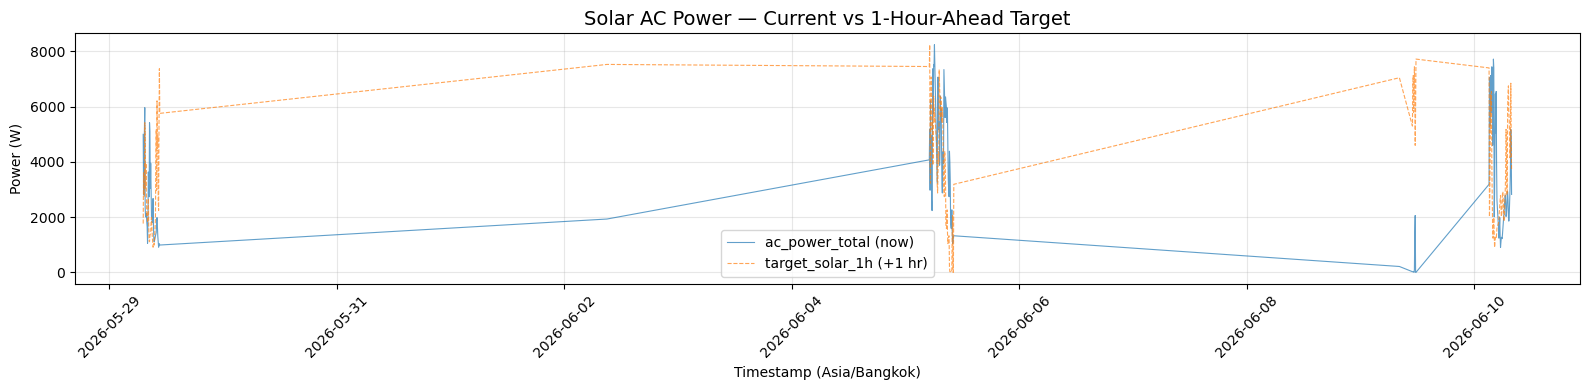

In [47]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Exploratory Validation
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(f"df.shape   : {df.shape}")
print("=" * 60)

print("\n── dtypes ──────────────────────────────────")
print(df.dtypes)

print("\n── describe ────────────────────────────────")
display(df.describe())

print("\n── null counts ─────────────────────────────")
print(df.isnull().sum())

# ── Plot ac_power_total vs target_solar_1h ────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Convert to Bangkok time for the plot axis
local_ts = df.index.tz_convert("Asia/Bangkok")

ax.plot(local_ts, df["ac_power_total"],   label="ac_power_total (now)",    alpha=0.7, linewidth=0.8)
ax.plot(local_ts, df["target_solar_1h"],  label="target_solar_1h (+1 hr)", alpha=0.7, linewidth=0.8, linestyle="--")

ax.set_title("Solar AC Power — Current vs 1-Hour-Ahead Target", fontsize=14)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Train / Validation Split (Chronological)
# ─────────────────────────────────────────────────────────────

FEATURES = [
    # Current solar signal
    "ac_power_total",
    # Lag features
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_6", "lag_12",
    # Rolling features
    "rolling_mean_6", "rolling_std_6",
    # Current weather observations
    "solar_irradiance", "cloud_cover",
    # Forecast weather
    "solar_irradiance_forecast_1h", "cloud_cover_forecast_1h",
    # Time features
    "hour_of_day", "day_of_week",
]

TARGET = "target_solar_1h"

# Chronological 80/20 split — no shuffling
split_idx = int(len(df) * 0.8)

df_train = df.iloc[:split_idx]
df_val   = df.iloc[split_idx:]

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_val   = df_val[FEATURES]
y_val   = df_val[TARGET]

print(f"Total rows   : {len(df):,}")
print(f"Train rows   : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val rows     : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Feature count: {len(FEATURES)}")
print(f"Features     : {FEATURES}")

Total rows   : 166
Train rows   : 132  (79.5%)
Val rows     : 34  (20.5%)
Feature count: 15
Features     : ['ac_power_total', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'rolling_mean_6', 'rolling_std_6', 'solar_irradiance', 'cloud_cover', 'solar_irradiance_forecast_1h', 'cloud_cover_forecast_1h', 'hour_of_day', 'day_of_week']


In [49]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Train LightGBM Model
# ─────────────────────────────────────────────────────────────

params = {
    "objective"    : "regression",
    "metric"       : "rmse",
    "learning_rate": 0.05,
    "num_leaves"   : 31,
    "n_estimators" : 500,
    "verbosity"    : -1,
    "random_state" : 42,
}

model = lgb.LGBMRegressor(**params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✅ Training complete")
print(f"   Best iteration : {model.best_iteration_}")
print(f"   Best val RMSE  : {model.best_score_['valid_0']['rmse']:.2f} W")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2125.76
Early stopping, best iteration is:
[1]	valid_0's rmse: 1590.27

✅ Training complete
   Best iteration : 1
   Best val RMSE  : 1590.27 W


  Validation Metrics (Solar Power)
  RMSE : 1,590.27 W
  MAE  : 1,377.73 W


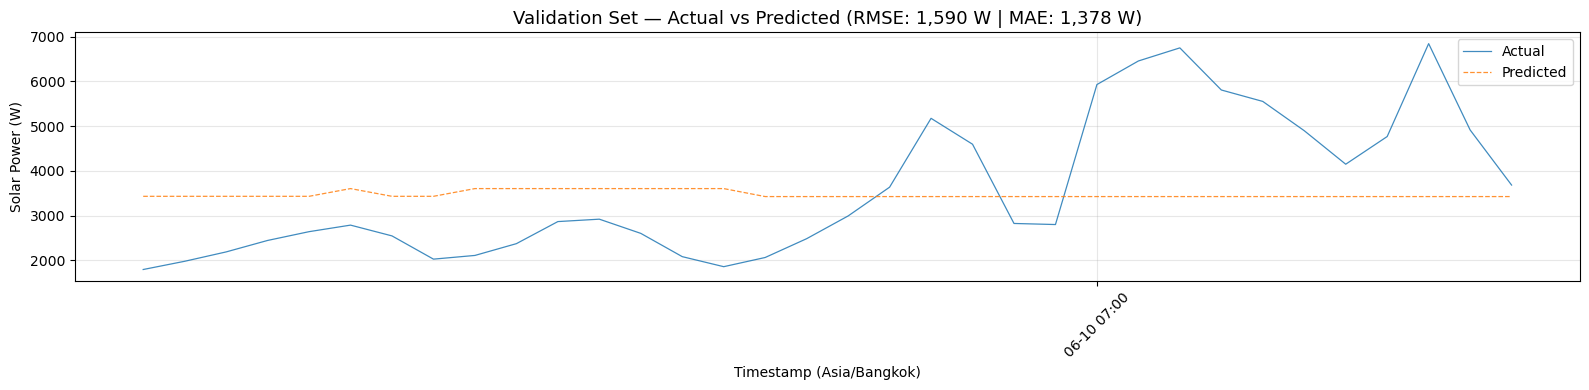

In [50]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("  Validation Metrics (Solar Power)")
print("=" * 40)
print(f"  RMSE : {rmse:,.2f} W")
print(f"  MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Actual vs Predicted plot ───────────────────────────────────
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")
plot_n = min(len(df_val), 12 * 24 * 3)   # plot up to 3 days of 5-min data

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(val_local_ts[:plot_n], y_val.values[:plot_n],  label="Actual",    linewidth=0.9, alpha=0.85)
ax.plot(val_local_ts[:plot_n], y_pred[:plot_n],        label="Predicted", linewidth=0.9, alpha=0.85, linestyle="--")
ax.set_title(f"Validation Set — Actual vs Predicted (RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ImportError: You must install matplotlib and restart your session to plot importance.

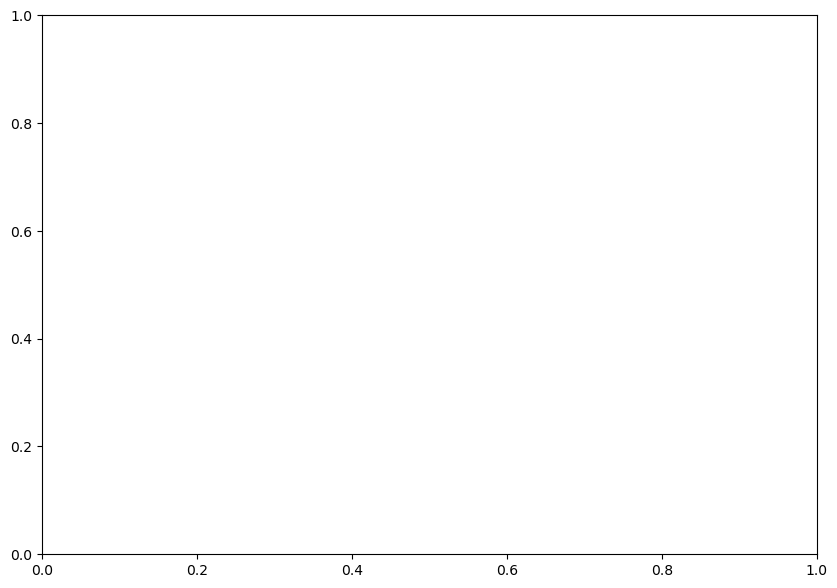

In [51]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Feature Importance
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))
lgb.plot_importance(
    model,
    ax=ax,
    importance_type="gain",
    max_num_features=18,
    title="LightGBM Feature Importance (by Gain)",
    xlabel="Gain",
)
plt.tight_layout()
plt.show()

# ── Tabular view ───────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature"   : model.feature_name_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n── Feature Importances (gain) ──────────────")
display(importance_df)

print("\n💡 Interpretation tips:")
print("   • High-importance lag/rolling features → strong auto-regression signal")
print("   • High-importance irradiance/cloud features → weather is predictive")
print("   • Low-importance features → candidates for removal in next iteration")